## Title :

Exercise: Feature Importance

The goal of this exercise is to compare two feature importance methods; MDI, and Permutation Importance. For a discussion on the merits of each go to this <a href="https://scikit-learn.org/stable/modules/permutation_importance.html" target="_blank">link</a>.

## Description :

![fig2](fig/fig2.png)

## Instructions:

- Read the dataset `heart.csv` as a pandas dataframe, and take a quick look at the data.
- Assign the predictor and response variables as per the instructions given in the scaffold.
- Set a max_depth value.
- Define a `DecisionTreeClassifier` and fit on the entire data.
- Define a `RandomForestClassifier` and fit on the entire data.
- Calculate Permutation Importance for each of the two models. Remember that the MDI is automatically computed by sklearn when you call the classifiers.
- Use the routines provided to display the feature importance of bar plots. The plots will look similar to the one given above.

## Hints: 

<a href="https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html#" target="_blank">forest.feature_importances_</a>
Calculate the impurity-based feature importance.

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html#sklearn.inspection.permutation_importance" target="_blank">sklearn.inspection.permutation_importance()</a>
Calculate the permutation-based feature importance.

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html" target="_blank">sklearn.RandomForestClassifier()</a>
Returns a random forest classifier object.

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html" target="_blank">sklearn.DecisionTreeClassifier()</a>
Returns a decision tree classifier object.


**NOTE** - MDI is automatically computed by sklearn by calling RandomForestClassifier and/or DecisionTreeClassifier.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
from helper import plot_permute_importance, plot_feature_importance

%matplotlib inline


In [2]:
# Read the dataset "heart.csv"
df = pd.read_csv("../Lecture 15/data/Heart.csv")

# Take a quick look at the data 
df.head()


,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [3]:
# Assign the predictor and response variables.

# 'AHD' is the response and all the other columns are the predictors
X = df.drop("AHD", axis=1)
y = df["AHD"]


In [4]:
# Set the model parameters

# The random state is fized for testing purposes
random_state = 44

# Choose a `max_depth` for your trees 
max_depth = 5


### SINGLE TREE

In [5]:
### edTest(test_decision_tree) ###

# Define a Decision Tree classifier with random_state as the above defined variable
# Set the maximum depth to be max_depth
tree = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)

# Fit the model on the entire data
X_encoded = pd.get_dummies(X)
y_encoded = y.map({"No": 0, "Yes": 1})
tree.fit(X_encoded, y_encoded);

# Using Permutation Importance to get the importance of features for the Decision Tree 
# with random_state as the above defined variable
tree_result = permutation_importance(tree, X_encoded, y_encoded, random_state=random_state)


### RANDOM FOREST

In [6]:
### edTest(test_random_forest) ###

# Define a Random Forest classifier with random_state as the above defined variable
# Set the maximum depth to be max_depth and use 10 estimators
forest = RandomForestClassifier(n_estimators=10, max_depth=max_depth, random_state=random_state)

# Fit the model on the entire data
forest.fit(X_encoded, y_encoded);

# Use Permutation Importance to get the importance of features for the Random Forest model 
# with random_state as the above defined variable
forest_result = permutation_importance(forest, X_encoded, y_encoded, random_state=random_state)


### PLOTTING THE FEATURE RANKING

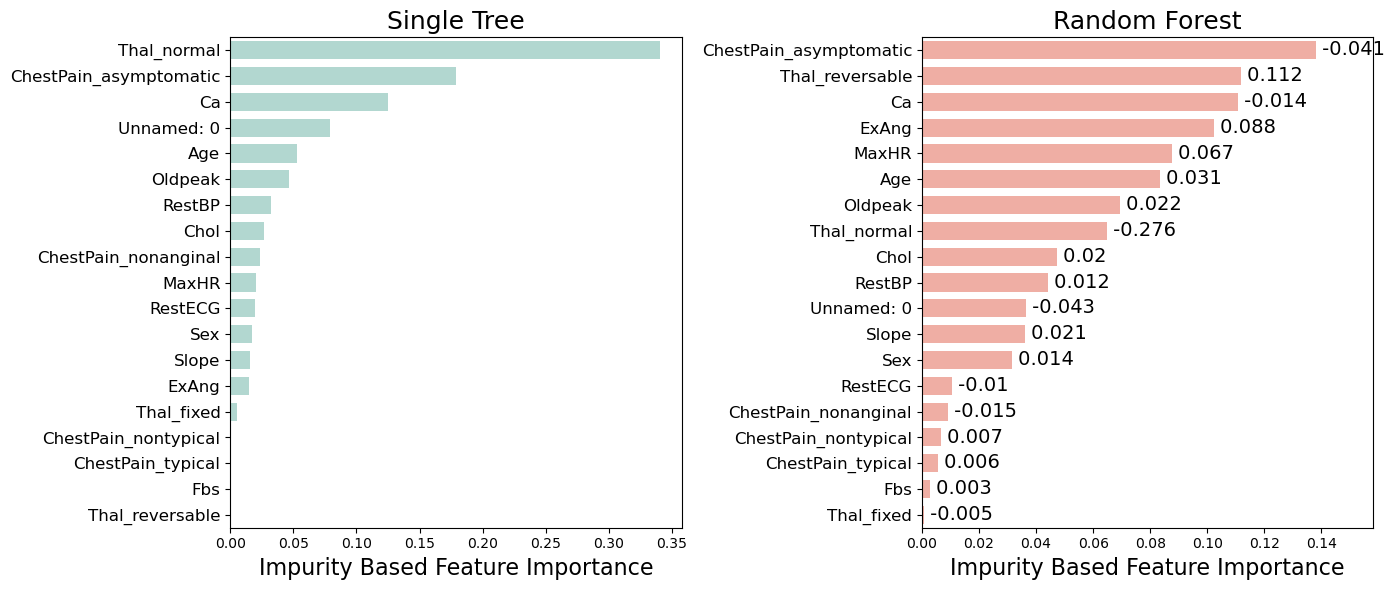

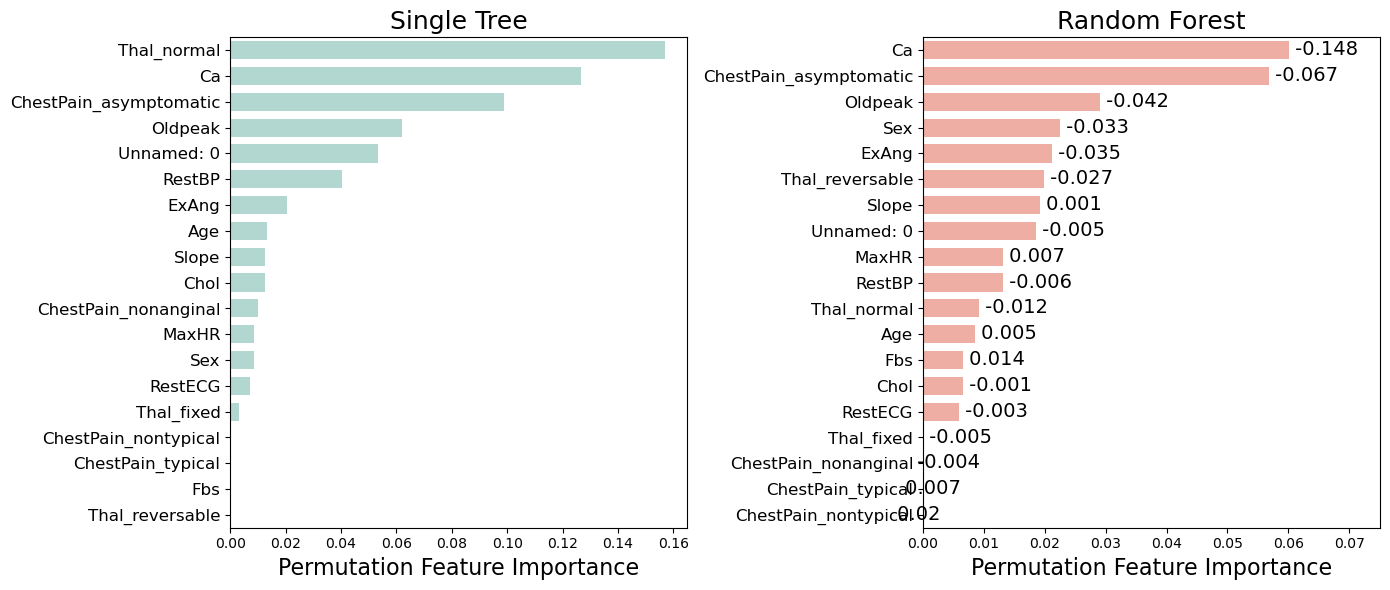

In [7]:
# Helper code to visualize the feature importance using 'MDI'
plot_feature_importance(tree,forest,X_encoded,y_encoded);

# Helper code to visualize the feature importance using 'permutation feature importance'
plot_permute_importance(tree_result,forest_result,X_encoded,y_encoded);


⏸ A common criticism for the MDI method is that it assigns a lot of importance to noisy features (more here). Did you make such an observation in the plots above?

In [8]:
### edTest(test_chow1) ###
# Type your answer within in the quotes given
answer1 = '___'


⏸ After marking, change the max_depth for your classifiers to a very low value such as 
3
3, and see if you see a change in the relative importance of predictors.

In [9]:
### edTest(test_chow2) ###
# Type your answer within in the quotes given
answer2 = '___'
